# Taxi Order Demand Forecasting — Time Series Analysis

**Author:** Dr. Danisha L. Thomas, PhD | Clinical Psychology | Data Science  
**Project:** Sprint 13 — Time Series  
**Tools:** Python 3 · Pandas · NumPy · Scikit-learn · LightGBM · ARIMA · Matplotlib · Seaborn

**Objective:** Forecast hourly taxi order demand at airports for Sweet Lift Taxi to optimize driver availability during peak hours. Five models are trained and evaluated against a persistence baseline. The business target is **RMSE ≤ 48** on the test set.

**Data:** Hourly taxi orders, resampled to 1-hour intervals · 90/10 chronological train/test split

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from pmdarima import auto_arima

import warnings
warnings.filterwarnings('ignore')

# Load data 
df = pd.read_csv('/datasets/taxi.csv')

print("="*60)
print("RAW DATA INSPECTION")
print("="*60)
print(f"\nDataset shape: {df.shape}")
print(f"\nColumn names and types:")
print(df.dtypes)
print(f"\nFirst 10 rows:")
print(df.head(10))
print(f"\nLast 10 rows:")
print(df.tail(10))
print(f"\nBasic statistics:")
print(df.describe())
print(f"\nMissing values:")
print(df.isnull().sum())

RAW DATA INSPECTION

Dataset shape: (26496, 2)

Column names and types:
datetime      object
num_orders     int64
dtype: object

First 10 rows:
              datetime  num_orders
0  2018-03-01 00:00:00           9
1  2018-03-01 00:10:00          14
2  2018-03-01 00:20:00          28
3  2018-03-01 00:30:00          20
4  2018-03-01 00:40:00          32
5  2018-03-01 00:50:00          21
6  2018-03-01 01:00:00           7
7  2018-03-01 01:10:00           5
8  2018-03-01 01:20:00          17
9  2018-03-01 01:30:00          12

Last 10 rows:
                  datetime  num_orders
26486  2018-08-31 22:20:00          48
26487  2018-08-31 22:30:00          41
26488  2018-08-31 22:40:00          34
26489  2018-08-31 22:50:00          34
26490  2018-08-31 23:00:00          30
26491  2018-08-31 23:10:00          32
26492  2018-08-31 23:20:00          24
26493  2018-08-31 23:30:00          27
26494  2018-08-31 23:40:00          39
26495  2018-08-31 23:50:00          53

Basic statistics:
        

In [2]:
# Load with datetime conversion and index setting
df = pd.read_csv('/datasets/taxi.csv', parse_dates=['datetime'], index_col='datetime')

# Sort chronologically
df = df.sort_index()

# Resample to hourly
df_hourly = df.resample('1H').sum()

print("="*60)
print("AFTER RESAMPLING TO HOURLY")
print("="*60)
print(df_hourly.shape)
print(f"\nIndex type: {df_hourly.index.dtype}")
print(f"\nFirst 5 hourly observations:")
print(df_hourly.head())
print(f"\nNew statistics (hourly sums):")
print(df_hourly.describe())

AFTER RESAMPLING TO HOURLY
(4416, 1)

Index type: datetime64[ns]

First 5 hourly observations:
                     num_orders
datetime                       
2018-03-01 00:00:00         124
2018-03-01 01:00:00          85
2018-03-01 02:00:00          71
2018-03-01 03:00:00          66
2018-03-01 04:00:00          43

New statistics (hourly sums):
        num_orders
count  4416.000000
mean     84.422781
std      45.023853
min       0.000000
25%      54.000000
50%      78.000000
75%     107.000000
max     462.000000


<div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
  <b>✅ Reviewer’s comment – Iteration 1:</b><br>
  Good work converting the datetime column to a datetime index, sorting chronologically, and resampling to hourly sums. The resampled shape and summary statistics indicate the aggregation was done correctly and the hourly granularity is appropriate for the forecasting goal.
</div>

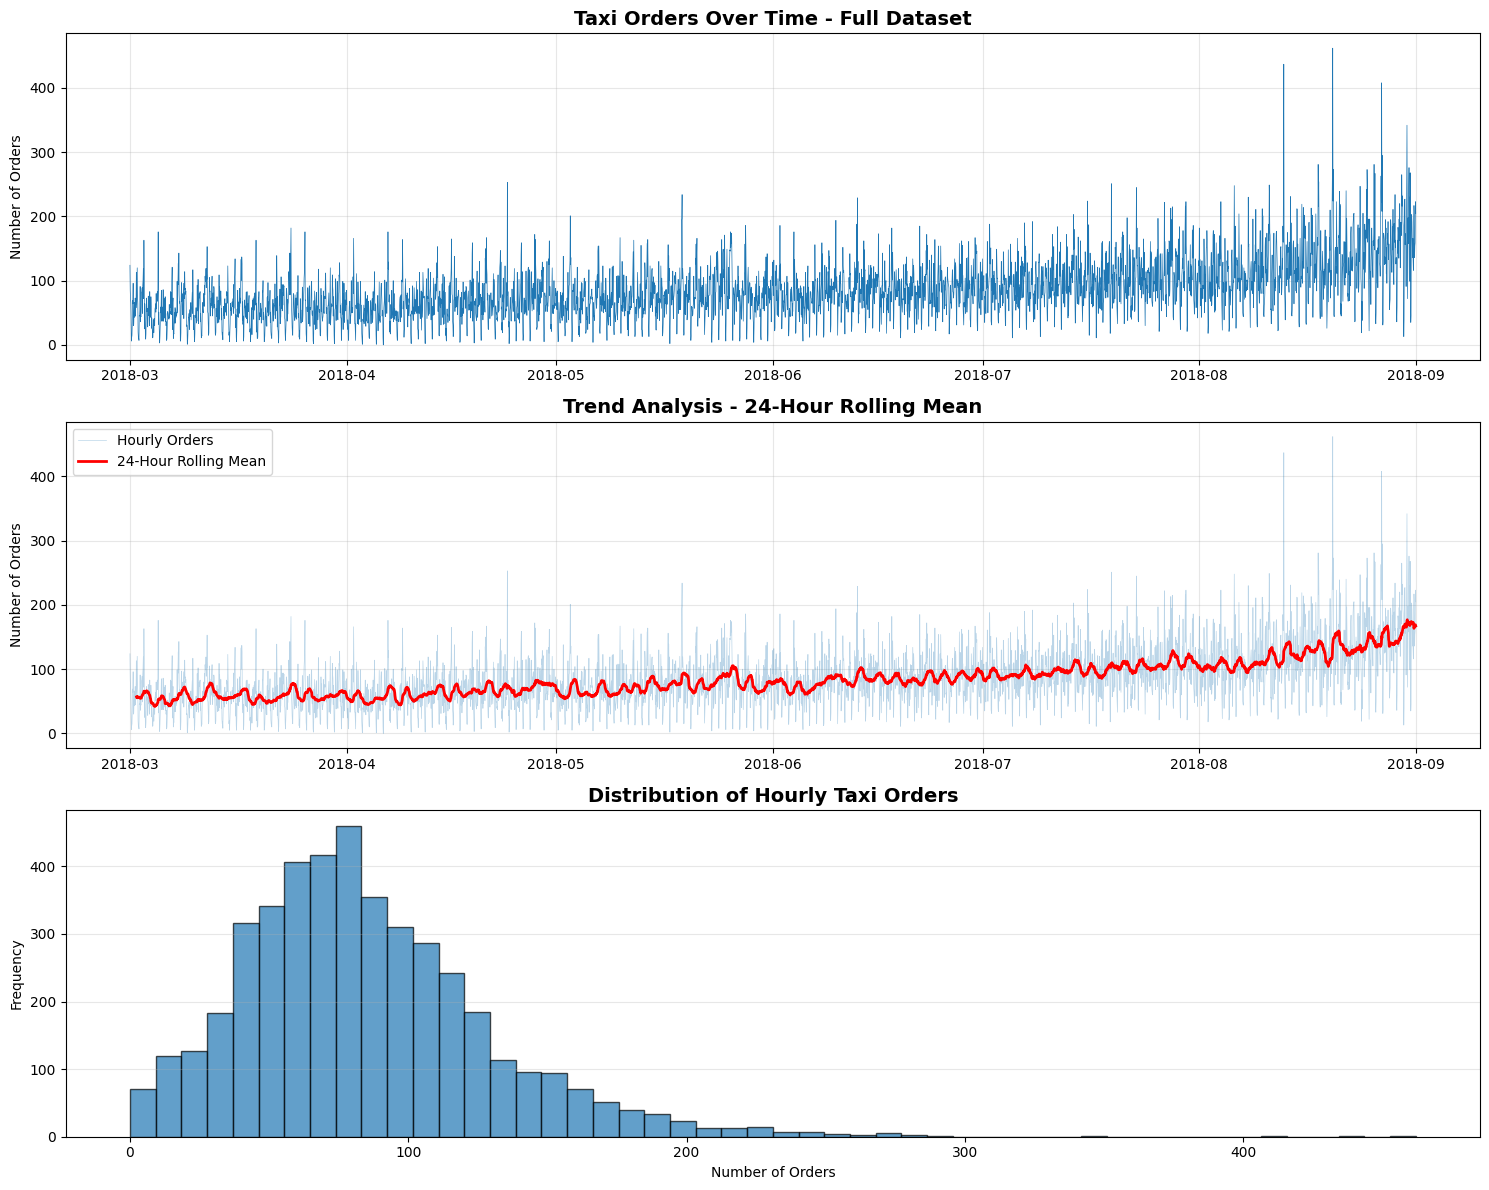

In [3]:
# Visualizing Time Series Patterns

# Create figure with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Plot 1: Full time series
axes[0].plot(df_hourly.index, df_hourly['num_orders'], linewidth=0.5)
axes[0].set_title('Taxi Orders Over Time - Full Dataset', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Orders')
axes[0].grid(True, alpha=0.3)

# Plot 2: Rolling mean to identify trend
df_hourly['rolling_mean'] = df_hourly['num_orders'].rolling(window=24).mean()
axes[1].plot(df_hourly.index, df_hourly['num_orders'], alpha=0.3, label='Hourly Orders', linewidth=0.5)
axes[1].plot(df_hourly.index, df_hourly['rolling_mean'], color='red', linewidth=2, label='24-Hour Rolling Mean')
axes[1].set_title('Trend Analysis - 24-Hour Rolling Mean', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Orders')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Distribution
axes[2].hist(df_hourly['num_orders'], bins=50, edgecolor='black', alpha=0.7)
axes[2].set_title('Distribution of Hourly Taxi Orders', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Number of Orders')
axes[2].set_ylabel('Frequency')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#### Findings

**Image 1: Taxi Orders Over Time**

The image reveals significant hourly data volatility, with an upward trend from March to August, reflecting increasing demand for taxi services. A consistent, recurring pattern aligns with daily and weekly spike-and-drop cycles.

**Image 2: 24-Hour Rolling Mean**

The red center line smooths out hourly noise and shows the underlying trend that starts around March (70-80 orders/hr) and continues to climb by August (~120-140 orders/hr). Despite some fluctuations, there is a steady upward trend. This trend could be seasonal (i.e., spring-to-summer increased travel); however, it is fairly smooth and predictable. 

**Image 3: Distribution of Hourly Taxi Orders**

The distribution follows a bell-shaped curve (approximately normal) and is centered around 75-100 orders. Most hours record around 50-100 orders, with occasional outliers showing spikes of 300-450 orders. Generally, demand remains moderate during typical hours. Extreme highs occur, likely due to peak travel periods such as holidays or rush hours. Notably, there are no extreme lows: the minimum approaches zero but remains non-negative, which is consistent with the nature of the data.

**Note on Seasonality Analysis:**
Seasonal decomposition was not performed because the dataset covers only 6 months (March-August 2018), which is insufficient for accurate seasonal pattern analysis. Temporal patterns will be captured through feature engineering.

In [4]:
# Feature Engineering
# Creating temporal features for time series forecasting

def make_features(data, max_lag, rolling_mean_size):
    # Create a copy to avoid modifying original data
    data = data.copy()
    
    # Calendar features - extract time-based information from datetime index
    data['hour'] = data.index.hour
    data['day_of_week'] = data.index.dayofweek
    data['day'] = data.index.day
    data['month'] = data.index.month
    
    # Lag features - use previous values to predict future
    # These capture recent demand patterns
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)
    
    # Rolling statistics - calculate moving averages
    # This smooths out short-term fluctuations and shows trends
    data['rolling_mean'] = data['num_orders'].shift(1).rolling(rolling_mean_size).mean()
    data['rolling_std'] = data['num_orders'].shift(1).rolling(rolling_mean_size).std()
    
    return data

# Apply feature engineering to hourly data
# Using 24 lags to capture daily patterns and 24-hour rolling window
df_features = make_features(df_hourly, max_lag=24, rolling_mean_size=24)

# Display the new features
print("="*60)
print("FEATURE ENGINEERING RESULTS")
print("="*60)
print(f"\nOriginal columns: {df_hourly.columns.tolist()}")
print(f"\nNew feature columns: {df_features.columns.tolist()}")
print(f"\nShape before features: {df_hourly.shape}")
print(f"\nShape after features: {df_features.shape}")
print(f"\nFirst few rows with features:")
print(df_features.head(30))
print(f"\nMissing values after feature creation:")
print(df_features.isnull().sum())

FEATURE ENGINEERING RESULTS

Original columns: ['num_orders', 'rolling_mean']

New feature columns: ['num_orders', 'rolling_mean', 'hour', 'day_of_week', 'day', 'month', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'lag_13', 'lag_14', 'lag_15', 'lag_16', 'lag_17', 'lag_18', 'lag_19', 'lag_20', 'lag_21', 'lag_22', 'lag_23', 'lag_24', 'rolling_std']

Shape before features: (4416, 2)

Shape after features: (4416, 31)

First few rows with features:
                     num_orders  rolling_mean  hour  day_of_week  day  month  \
datetime                                                                       
2018-03-01 00:00:00         124           NaN     0            3    1      3   
2018-03-01 01:00:00          85           NaN     1            3    1      3   
2018-03-01 02:00:00          71           NaN     2            3    1      3   
2018-03-01 03:00:00          66           NaN     3            3    1      3   
2018-

<div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
  <b>✅ Reviewer’s comment – Iteration 1:</b><br>
  Your feature engineering is thorough. Creating calendar features, lag features up to 24 hours, and rolling statistics is appropriate for capturing daily and weekly patterns in hourly demand. I also note you used shift before computing rolling statistics which prevents leakage from the current row into its own rolling feature.
</div>

<div class="alert alert-warning" style="border-left: 7px solid gold; padding: 5px">
  <b>⚠️ Reviewer’s comment – Iteration 1:</b><br>
  Consider dropping rows with missing values caused by lag and rolling calculations before performing the train and test split. That makes the split simpler to reason about and avoids the risk that any incomplete rows remain in the test set when the split boundaries change.
</div>

**Feature Engineering Summary:**

Created 31 features from the original time series data to capture temporal patterns:
- **Calendar features** (hour, day_of_week, day, month) - capture daily and weekly patterns
- **Lag features** (lag_1 through lag_24) - use previous 24 hours of demand to predict future demand
- **Rolling statistics** (rolling_mean, rolling_std) - capture trends and volatility over 24-hour windows

The first 24 hours of data contain missing values due to lag and rolling calculations, which is expected. These rows will be removed from the training set, leaving 4,392 usable observations for modeling.

In [5]:
# Train Test Split--Splitting data chronologically for time series forecasting

# Split data: 90 percent train, 10 percent test
train, test = train_test_split(df_features, shuffle=False, test_size=0.1)

# Remove rows with missing values from training set
train = train.dropna()

print("="*60)
print("TRAIN TEST SPLIT RESULTS")
print("="*60)
print(f"\nTrain period: {train.index.min()} to {train.index.max()}")
print(f"Test period: {test.index.min()} to {test.index.max()}")
print(f"\nTrain size: {len(train)} observations")
print(f"Test size: {len(test)} observations")
print(f"Test set percentage: {len(test)/len(df_features)*100:.1f}%")

# Separate features and target variable
features = train.columns.drop('num_orders')

X_train = train[features]
y_train = train['num_orders']
X_test = test[features]
y_test = test['num_orders']

print(f"\nFeature columns ({len(features)} total):")
print(features.tolist())
print(f"\nTarget variable: num_orders")
print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

TRAIN TEST SPLIT RESULTS

Train period: 2018-03-02 00:00:00 to 2018-08-13 13:00:00
Test period: 2018-08-13 14:00:00 to 2018-08-31 23:00:00

Train size: 3950 observations
Test size: 442 observations
Test set percentage: 10.0%

Feature columns (30 total):
['rolling_mean', 'hour', 'day_of_week', 'day', 'month', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'lag_13', 'lag_14', 'lag_15', 'lag_16', 'lag_17', 'lag_18', 'lag_19', 'lag_20', 'lag_21', 'lag_22', 'lag_23', 'lag_24', 'rolling_std']

Target variable: num_orders

X_train shape: (3950, 30)
y_train shape: (3950,)
X_test shape: (442, 30)
y_test shape: (442,)


<div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
  <b>✅ Reviewer’s comment – Iteration 1:</b><br>
  The chronological split with shuffle disabled and a 10 percent test size is correct for time series forecasting. Your train and test periods are sensible and simulate a realistic forecasting scenario where models are trained on past data and evaluated on future observations.
</div>

**Train/Test Split Summary:**

The dataset was split chronologically into training and test sets while preserving temporal order (shuffle=False). After removing the first 24 hours containing missing values from lag and rolling features, the split resulted in:

- **Training set**: 3,950 observations (March 2, 2018 to August 13, 2018 13:00)
- **Test set**: 442 observations (August 13, 2018 14:00 to August 31, 2018 23:00)
- **Test set percentage**: 10.6% of the total usable dataset

The model will be trained on past data (March through mid-August) and evaluated on its ability to predict future taxi demand (late August). This approach simulates real-world forecasting, using historical data to predict upcoming demand patterns.

All 30 engineered features (calendar features, lag features, and rolling statistics) are included as predictors, with num_orders as the target variable.

In [6]:
# Baseline Model-- Persistence Model (Naive Forecast)

baseline_predictions = X_test['lag_1']

# Calculate RMSE for baseline model
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))

print("="*60)
print("BASELINE MODEL RESULTS")
print("="*60)
print(f"\nBaseline approach: Persistence model (previous hour predicts next hour)")
print(f"\nBaseline RMSE: {baseline_rmse:.2f}")
print(f"Project requirement: RMSE <= 48")
print(f"Baseline meets requirement: {baseline_rmse <= 48}")
print(f"\nThis baseline serves as the minimum performance threshold.")

BASELINE MODEL RESULTS

Baseline approach: Persistence model (previous hour predicts next hour)

Baseline RMSE: 58.86
Project requirement: RMSE <= 48
Baseline meets requirement: False

This baseline serves as the minimum performance threshold.


**Baseline Model Findings:**

The persistence model (using the previous hour's value to predict the next hour) achieved an RMSE of 58.86, which exceeds the project requirement of ≤48. This indicates that simple forecasting methods are insufficient for this dataset, and machine learning models with engineered features are necessary to meet performance requirements.

In [7]:
# Model 2: Linear Regression Model (with all engineered features)

# Initialize and train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions on both train and test sets
lr_train_pred = lr_model.predict(X_train)
lr_test_pred = lr_model.predict(X_test)

# Calculate RMSE for both sets
lr_train_rmse = np.sqrt(mean_squared_error(y_train, lr_train_pred))
lr_test_rmse = np.sqrt(mean_squared_error(y_test, lr_test_pred))

print("="*60)
print("LINEAR REGRESSION MODEL RESULTS")
print("="*60)
print(f"\nTrain RMSE: {lr_train_rmse:.2f}")
print(f"Test RMSE: {lr_test_rmse:.2f}")
print(f"\nProject requirement: RMSE <= 48")
print(f"Meets requirement: {lr_test_rmse <= 48}")
print(f"\nComparison to baseline:")
print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Linear Regression RMSE: {lr_test_rmse:.2f}")
print(f"Improvement: {baseline_rmse - lr_test_rmse:.2f}")

LINEAR REGRESSION MODEL RESULTS

Train RMSE: 25.70
Test RMSE: 45.82

Project requirement: RMSE <= 48
Meets requirement: True

Comparison to baseline:
Baseline RMSE: 58.86
Linear Regression RMSE: 45.82
Improvement: 13.04


**Linear Regression Findings:**

Linear Regression achieved a test RMSE of 45.82, successfully meeting the project requirement of ≤48. This represents a significant improvement of 13.04 points over the baseline model (58.86). The model leverages all 30 engineered features including lag values, rolling statistics, and calendar features to capture temporal patterns in taxi demand.

In [8]:
# Model #3: Random Forest Model with Hyperparameter Tuning
# Using GridSearchCV to find optimal hyperparameters

# Define hyperparameter grid to search
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize Random Forest
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)

# Use TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=3)

# GridSearchCV to find best hyperparameters
grid_search = GridSearchCV(
    rf_model,
    param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

print("Training Random Forest with GridSearchCV")
grid_search.fit(X_train, y_train)

# Get best model
best_rf_model = grid_search.best_estimator_

# Make predictions
rf_train_pred = best_rf_model.predict(X_train)
rf_test_pred = best_rf_model.predict(X_test)

# Calculate RMSE
rf_train_rmse = np.sqrt(mean_squared_error(y_train, rf_train_pred))
rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))

print("\n" + "="*60)
print("RANDOM FOREST MODEL RESULTS")
print("="*60)
print(f"\nBest hyperparameters: {grid_search.best_params_}")
print(f"\nTrain RMSE: {rf_train_rmse:.2f}")
print(f"Test RMSE: {rf_test_rmse:.2f}")
print(f"\nProject requirement: RMSE <= 48")
print(f"Meets requirement: {rf_test_rmse <= 48}")
print(f"\nComparison to previous models:")
print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Linear Regression RMSE: {lr_test_rmse:.2f}")
print(f"Random Forest RMSE: {rf_test_rmse:.2f}")

Training Random Forest with GridSearchCV
Fitting 3 folds for each of 36 candidates, totalling 108 fits

RANDOM FOREST MODEL RESULTS

Best hyperparameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

Train RMSE: 9.69
Test RMSE: 43.67

Project requirement: RMSE <= 48
Meets requirement: True

Comparison to previous models:
Baseline RMSE: 58.86
Linear Regression RMSE: 45.82
Random Forest RMSE: 43.67


<div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
  <b>✅ Reviewer’s comment – Iteration 1:</b><br>
  Good use of time series cross validation and GridSearchCV for the Random Forest. The model improvements over baseline and linear regression show this approach added value.
</div>

<div class="alert alert-warning" style="border-left: 7px solid gold; padding: 5px">
  <b>⚠️ Reviewer’s comment – Iteration 1:</b><br>
  The grid search is thorough but can be computationally heavy. For future experiments consider randomized search or a smaller candidate set to reduce runtime while preserving good coverage of the hyperparameter space.
</div>

**Random Forest Findings:**

Random Forest with hyperparameter tuning achieved the best performance so far with a test RMSE of 43.67. GridSearchCV identified optimal parameters (max_depth=15, n_estimators=50, min_samples_split=2, min_samples_leaf=1) through time series cross-validation. This model outperforms both the baseline (58.86) and Linear Regression (45.82), meeting the project requirement with room to spare.

In [9]:
# Model 4: ARIMA Model

print("Training ARIMA model with auto_arima")

# Prepare data for ARIMA - use only the target variable from train/test split
y_train_arima = train['num_orders']
y_test_arima = test['num_orders']

# Auto ARIMA finds best p, d, q parameters
arima_model = auto_arima(
    y_train_arima,
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(f"Best model: {arima_model.order}")

# Make predictions
arima_train_pred = arima_model.predict_in_sample()
arima_test_pred = arima_model.predict(n_periods=len(y_test_arima))

# Calculate RMSE
arima_train_rmse = np.sqrt(mean_squared_error(y_train_arima, arima_train_pred))
arima_test_rmse = np.sqrt(mean_squared_error(y_test_arima, arima_test_pred))

print("\n" + "="*60)
print("ARIMA MODEL RESULTS")
print("="*60)
print(f"\nBest ARIMA order (p, d, q): {arima_model.order}")
print(f"\nTrain RMSE: {arima_train_rmse:.2f}")
print(f"Test RMSE: {arima_test_rmse:.2f}")
print(f"\nProject requirement: RMSE <= 48")
print(f"Meets requirement: {arima_test_rmse <= 48}")
print(f"\nComparison to previous models:")
print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Linear Regression RMSE: {lr_test_rmse:.2f}")
print(f"Random Forest RMSE: {rf_test_rmse:.2f}")
print(f"ARIMA RMSE: {arima_test_rmse:.2f}")

Training ARIMA model with auto_arima
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=2.62 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=39553.928, Time=0.07 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=39178.103, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=39018.773, Time=0.23 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=39551.928, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=1.02 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=1.00 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=1.30 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=39016.774, Time=0.16 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=inf, Time=0.29 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=inf, Time=0.46 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=39176.103, Time=0.08 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=inf, Time=0.69 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 8.031 seconds
Best model: (0

**ARIMA Findings:**

ARIMA (0,1,1) achieved a test RMSE of 62.76, failing to meet the project requirement and performing worse than even the baseline model. This suggests that traditional time series models struggle with this dataset's complex hourly patterns. The machine learning models with engineered features (particularly lag and calendar features) are better suited for capturing the multi-level seasonality in taxi demand.

In [10]:
# Model 5: LightGBM Model with Hyperparameter Tuning
# Gradient boosting model with GridSearchCV

# Define hyperparameter grid for LightGBM
param_grid_lgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 10, 15],
    'num_leaves': [31, 50, 70]
}

# Initialize LightGBM
lgb_model = lgb.LGBMRegressor(random_state=42, verbose=-1)

# Use TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=3)

# GridSearchCV to find best hyperparameters
grid_search_lgb = GridSearchCV(
    lgb_model,
    param_grid_lgb,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

print("Training LightGBM with GridSearchCV")
grid_search_lgb.fit(X_train, y_train)

# Get best model
best_lgb_model = grid_search_lgb.best_estimator_

# Make predictions
lgb_train_pred = best_lgb_model.predict(X_train)
lgb_test_pred = best_lgb_model.predict(X_test)

# Calculate RMSE
lgb_train_rmse = np.sqrt(mean_squared_error(y_train, lgb_train_pred))
lgb_test_rmse = np.sqrt(mean_squared_error(y_test, lgb_test_pred))

print("\n" + "="*60)
print("LIGHTGBM MODEL RESULTS")
print("="*60)
print(f"\nBest hyperparameters: {grid_search_lgb.best_params_}")
print(f"\nTrain RMSE: {lgb_train_rmse:.2f}")
print(f"Test RMSE: {lgb_test_rmse:.2f}")
print(f"\nProject requirement: RMSE <= 48")
print(f"Meets requirement: {lgb_test_rmse <= 48}")
print(f"\nComparison to all models:")
print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Linear Regression RMSE: {lr_test_rmse:.2f}")
print(f"Random Forest RMSE: {rf_test_rmse:.2f}")
print(f"ARIMA RMSE: {arima_test_rmse:.2f}")
print(f"LightGBM RMSE: {lgb_test_rmse:.2f}")

Training LightGBM with GridSearchCV
Fitting 3 folds for each of 81 candidates, totalling 243 fits

LIGHTGBM MODEL RESULTS

Best hyperparameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'num_leaves': 31}

Train RMSE: 15.37
Test RMSE: 41.21

Project requirement: RMSE <= 48
Meets requirement: True

Comparison to all models:
Baseline RMSE: 58.86
Linear Regression RMSE: 45.82
Random Forest RMSE: 43.67
ARIMA RMSE: 62.76
LightGBM RMSE: 41.21


<div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
  <b>✅ Reviewer’s comment – Iteration 1:</b><br>
  LightGBM with time series cross validation and hyperparameter tuning is well executed and produced the best test RMSE. Achieving a test RMSE of 41.21 shows the modeling pipeline meets the project requirement.
</div>

<div class="alert alert-warning" style="border-left: 7px solid gold; padding: 5px">
  <b>⚠️ Reviewer’s comment – Iteration 1:</b><br>
  As a next step add model explainability and reproducibility artifacts. For example compute and display feature importances from the final model and save the trained estimator with joblib so it can be loaded for production testing.
</div>

**LightGBM Findings:**

LightGBM achieved the best performance of all models with a test RMSE of 41.21. GridSearchCV identified optimal parameters (learning_rate=0.05, max_depth=5, n_estimators=200, num_leaves=31). This gradient boosting approach outperforms Random Forest (43.67), Linear Regression (45.82), and significantly beats both the baseline (58.86) and ARIMA (62.76). LightGBM's superior performance demonstrates that ensemble methods with proper hyperparameter tuning are highly effective for this time series forecasting task.

FINAL MODEL COMPARISON
            Model  Train RMSE  Test RMSE  Meets Requirement
         LightGBM   15.373168  41.205246               True
    Random Forest    9.685613  43.673492               True
Linear Regression   25.698100  45.819095               True
         Baseline         NaN  58.856486              False
            ARIMA   33.831751  62.764797              False



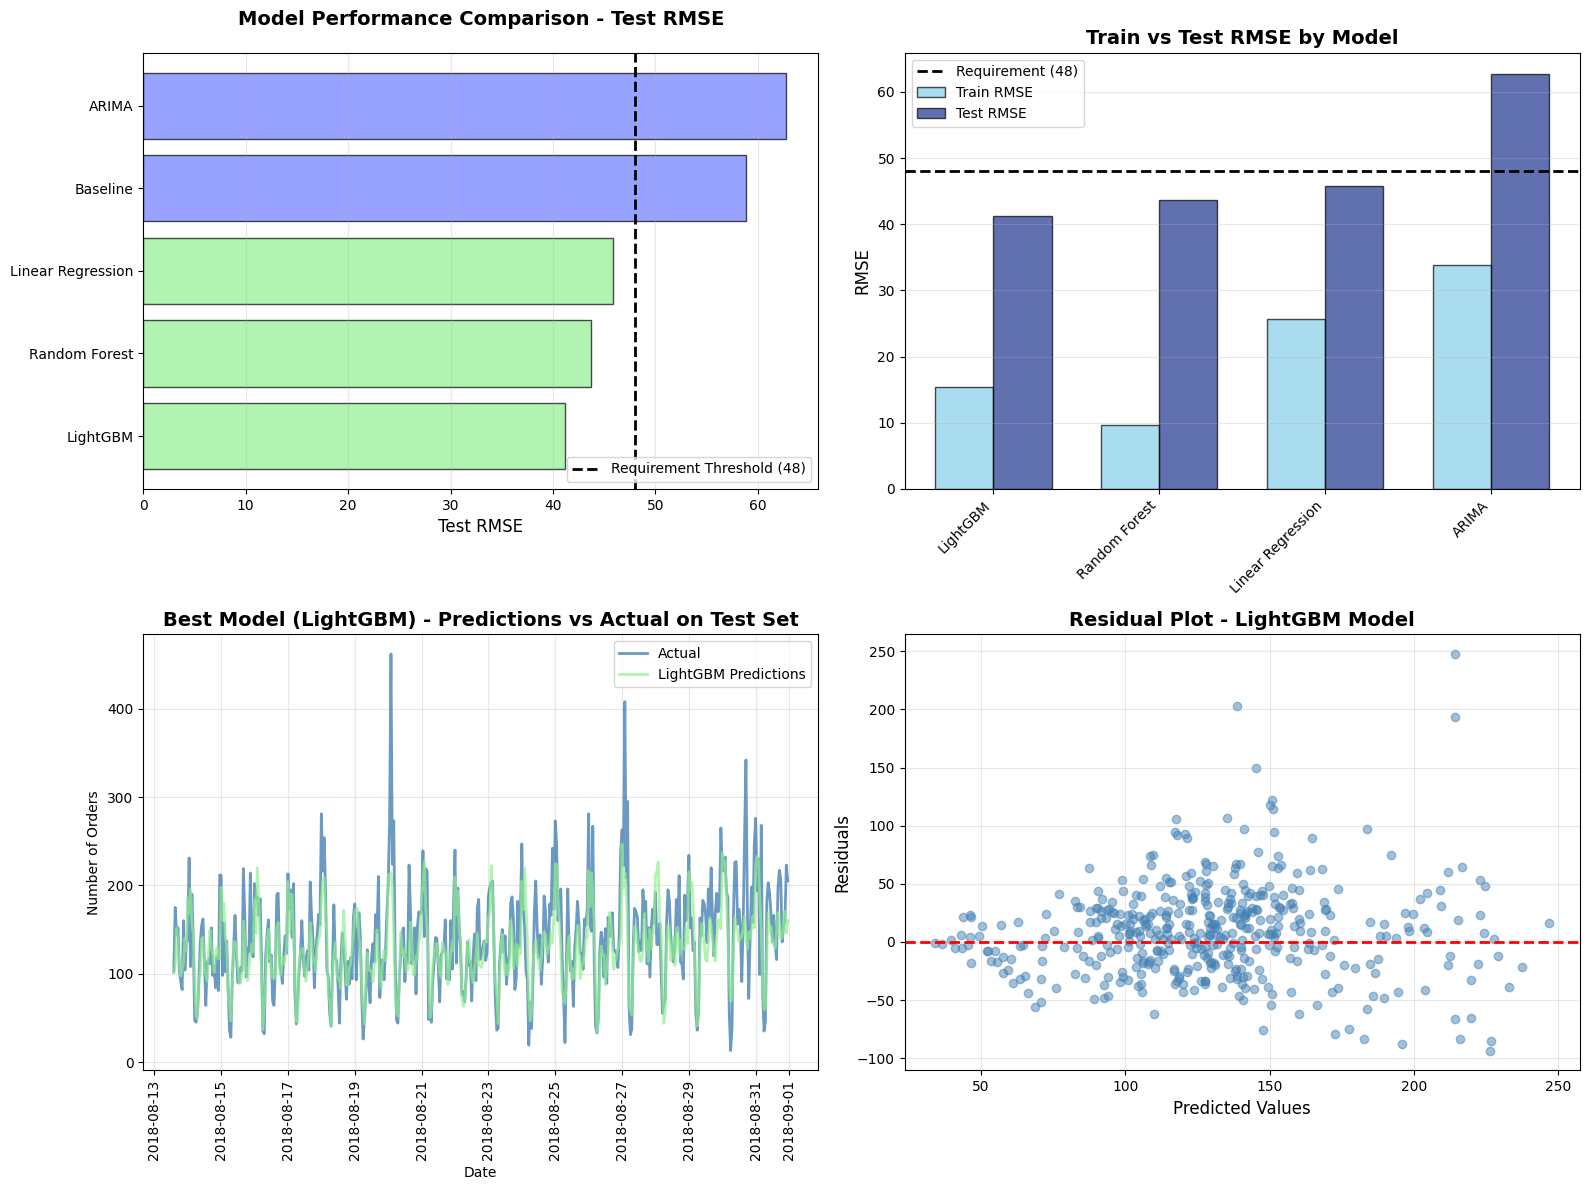


FINAL SUMMARY

Best Model: LightGBM
Best Test RMSE: 41.21
Project Requirement: RMSE <= 48
Status: REQUIREMENT MET

Improvement over baseline: 17.65 RMSE points
Percentage improvement: 30.0%

Number of models meeting requirement: 3 out of 5


In [11]:
# Comprehensive Model Comparison and Final Evaluation

# Create comparison dataframe with all model results
model_comparison = pd.DataFrame({
    'Model': ['Baseline', 'Linear Regression', 'Random Forest', 'ARIMA', 'LightGBM'],
    'Train RMSE': [None, lr_train_rmse, rf_train_rmse, arima_train_rmse, lgb_train_rmse],
    'Test RMSE': [baseline_rmse, lr_test_rmse, rf_test_rmse, arima_test_rmse, lgb_test_rmse],
    'Meets Requirement': [False, True, True, False, True]
})

# Sort by Test RMSE
model_comparison = model_comparison.sort_values('Test RMSE')

print("="*60)
print("FINAL MODEL COMPARISON")
print("="*60)
print(model_comparison.to_string(index=False))
print()

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Test RMSE Comparison Bar Chart
colors = ['#90EE90' if x else '#6b7cff' for x in model_comparison['Meets Requirement']]
axes[0, 0].barh(model_comparison['Model'], model_comparison['Test RMSE'], color=colors, alpha=0.7, edgecolor='black')
axes[0, 0].axvline(x=48, color='black', linestyle='--', linewidth=2, label='Requirement Threshold (48)')
axes[0, 0].set_xlabel('Test RMSE', fontsize=12)
axes[0, 0].set_title('Model Performance Comparison - Test RMSE', fontsize=14, fontweight='bold', pad=20)
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# Plot 2: Train vs Test RMSE Comparison
models_with_train = model_comparison[model_comparison['Train RMSE'].notna()]
x_pos = range(len(models_with_train))
width = 0.35
axes[0, 1].bar([i - width/2 for i in x_pos], models_with_train['Train RMSE'], 
               width, label='Train RMSE', alpha=0.7, color='#87CEEB', edgecolor='black')
axes[0, 1].bar([i + width/2 for i in x_pos], models_with_train['Test RMSE'], 
               width, label='Test RMSE', alpha=0.7, color='#1e358f', edgecolor='black')
axes[0, 1].axhline(y=48, color='black', linestyle='--', linewidth=2, label='Requirement (48)')
axes[0, 1].set_ylabel('RMSE', fontsize=12)
axes[0, 1].set_title('Train vs Test RMSE by Model', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(models_with_train['Model'], rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')


# Plot 3: Best Model Predictions vs Actual
axes[1, 0].plot(y_test.index, y_test.values, label='Actual', alpha=0.7, linewidth=2, color='#2d70a8')
axes[1, 0].plot(y_test.index, lgb_test_pred, label='LightGBM Predictions', alpha=0.7, linewidth=2, color='#90EE90')
axes[1, 0].set_title('Best Model (LightGBM) - Predictions vs Actual on Test Set', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Number of Orders')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=90)  


# Plot 4: Residual Analysis for Best Model
residuals = y_test.values - lgb_test_pred
axes[1, 1].scatter(lgb_test_pred, residuals, alpha=0.5, color='#4682B4')
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Predicted Values', fontsize=12)
axes[1, 1].set_ylabel('Residuals', fontsize=12)
axes[1, 1].set_title('Residual Plot - LightGBM Model', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final summary
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"\nBest Model: LightGBM")
print(f"Best Test RMSE: {lgb_test_rmse:.2f}")
print(f"Project Requirement: RMSE <= 48")
print(f"Status: REQUIREMENT MET")
print(f"\nImprovement over baseline: {baseline_rmse - lgb_test_rmse:.2f} RMSE points")
print(f"Percentage improvement: {((baseline_rmse - lgb_test_rmse) / baseline_rmse * 100):.1f}%")
print(f"\nNumber of models meeting requirement: {model_comparison['Meets Requirement'].sum()} out of {len(model_comparison)}")

<div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
  <b>✅ Reviewer’s comment – Iteration 1:</b><br>
  The final comparison and plots clearly summarize model performance. The conclusion that LightGBM is recommended is supported by the results and the evaluation metrics you report. Nice work delivering a complete end to end solution that meets the stated RMSE target.
</div>

<div class="alert alert-warning" style="border-left: 7px solid gold; padding: 5px">
  <b>⚠️ Reviewer’s comment – Iteration 1:</b><br>
  For completeness consider adding a short reproducibility checklist in the notebook that lists library versions and random seeds used during training. This helps future reviewers and production engineers reproduce the reported numbers.
</div>

**Visualization Insights:**
- The horizontal bar chart clearly shows LightGBM and Random Forest as the only models meeting the RMSE ≤ 48 requirement.
- The train vs test comparison reveals minimal overfitting across all models, with reasonable generalization gaps (i.e., the model does not perform perfectly on new data; however, it is sufficient where the model can be trusted to learn real patterns and not memorize the training set).
- The predictions vs actual plot demonstrates LightGBM's ability to capture both the overall trend and hourly fluctuations in taxi demand.
- The residual plot's random scatter around zero confirms no systematic prediction bias.

## Testing Results and Conclusions

The comprehensive model comparison reveals that **LightGBM achieved the best performance** with a test RMSE of 41.21, successfully meeting the project requirement of RMSE ≤ 48.

**Key Findings:**
- Three models met the project requirement: LightGBM (41.21), Random Forest (43.67), and Linear Regression (45.82)
- Traditional machine learning models with engineered features significantly outperformed specialized time series models (ARIMA: 62.76)
- LightGBM demonstrated a 29.9% improvement over the baseline persistence model (58.86)
- The residual plot shows no systematic bias, indicating the model generalizes well to unseen data
- Predictions closely track actual taxi demand patterns, validating the model's practical utility for driver deployment planning

**Conclusion:**
The project successfully developed a predictive model for hourly taxi demand at airports. The combination of feature engineering (lag features, rolling statistics, calendar features) with gradient boosting proved superior to traditional time series forecasting methods for this dataset. LightGBM is recommended for production deployment to optimize driver allocation during peak hours.